# Case Study Phase 4: Solution Reuse

## Objective
Use historical/past court decisions as a search baseline for new cases.

## Menghubungkan Notebook ke Google Drive

Untuk mengakses file yang ada di Google Drive Anda dari notebook Colab ini, Anda perlu me-mount Google Drive. Ini akan memungkinkan Colab melihat file-file Anda seolah-olah mereka ada di sistem file lokal.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Setelah Anda menjalankan sel di atas dan mengikuti instruksi otentikasi (Anda akan diminta untuk memberikan izin kepada Google Colab untuk mengakses Google Drive Anda), Google Drive Anda akan terpasang di direktori `/content/drive`.

Anda dapat menavigasi ke sana dan mengakses file Anda. Misalnya, jika Anda memiliki folder bernama `KasusStudiPhase4` di Drive Saya, Anda bisa mengaksesnya seperti ini:

```python
# Contoh: melihat isi folder di Google Drive
!ls "/content/drive/MyDrive/KasusStudiPhase4"

# Contoh: membaca file CSV dari Google Drive
# import pandas as pd
# df_from_drive = pd.read_csv("/content/drive/MyDrive/KasusStudiPhase4/nama_file_anda.csv")
# display(df_from_drive.head())
```

Anda dapat mengganti `"/content/drive/MyDrive/KasusStudiPhase4"` dengan path ke folder atau file spesifik Anda di Google Drive.

## Mengekstrak Teks dari File PDF di Google Drive

Sekarang kita akan membaca file-file PDF yang Anda miliki di Google Drive dan mengekstrak teksnya untuk digunakan sebagai `solution_text`.

In [38]:
import PyPDF2
import glob
import os

def extract_text_from_pdf(pdf_path):
    text = ""
    try:
        reader = PyPDF2.PdfReader(pdf_path)
        for page in reader.pages:
            text += page.extract_text() + "\n"
    except Exception as e:
        print(f"Error reading {pdf_path}: {e}")
    return text

user_data_folder = "/content/drive/MyDrive/Umm/SEMESTER 6/Penalaran_komputer/TUGAS_3_AKHIR/raw_pdf/"

pdf_files = glob.glob(os.path.join(user_data_folder, "**", "*.pdf"), recursive=True)

case_pdf_files = [f for f in pdf_files if 'putusan' in f.lower() or 'case_' in f.lower() or 'tugas_' in f.lower() or 'hasil_' in f.lower()]

# Update case_solutions dengan teks yang diekstrak
new_case_solutions = {}
for pdf_file in case_pdf_files:
    # Gunakan nama file tanpa ekstensi sebagai case_id
    case_id = os.path.basename(pdf_file).replace('.pdf', '')
    extracted_text = extract_text_from_pdf(pdf_file)
    if extracted_text:
        new_case_solutions[case_id] = extracted_text
    else:
        print(f"Could not extract text from {pdf_file}")

# Cetak beberapa contoh untuk verifikasi
print(f"Total {len(new_case_solutions)} solutions extracted from '{user_data_folder}'.")
if new_case_solutions:
    print("First 2 extracted solutions:")
    for i, (case_id, solution_text) in enumerate(new_case_solutions.items()):
        if i >= 2: break
        print(f"Case ID: {case_id}")
        print(f"Solution Snippet: {solution_text[:200]}...")
        print("\n---\n")
else:
    print("No PDF files found or text extracted in the specified folder.")

/usr/local/lib/python3.12/dist-packages/PyPDF2/_cmap.py:142: PdfReadWarning: Advanced encoding /SymbolSetEncoding not implemented yet
  warnings.warn(


Total 30 solutions extracted from '/content/drive/MyDrive/Umm/SEMESTER 6/Penalaran_komputer/TUGAS_3_AKHIR/raw_pdf/'.
First 2 extracted solutions:
Case ID: Case_005
Solution Snippet: Mahkamah Agung Republik Indonesia
Mahkamah Agung Republik Indonesia
Mahkamah Agung Republik Indonesia
Mahkamah Agung Republik Indonesia
Mahkamah Agung Republik Indonesia
Direktori Putusan Mahkamah Agu...

---

Case ID: Case_010
Solution Snippet: Mahkamah Agung Republik Indonesia
Mahkamah Agung Republik Indonesia
Mahkamah Agung Republik Indonesia
Mahkamah Agung Republik Indonesia
Mahkamah Agung Republik Indonesia
Direktori Putusan Mahkamah Agu...

---



# Tugas
Pengguna bermaksud menganalisis putusan pengadilan historis untuk memprediksi hasil kasus baru. Konfigurasi saat ini menggunakan data placeholder dan sistem pengambilan data tiruan. Tujuannya adalah untuk mengintegrasikan putusan pengadilan PDF aktual dari Google Drive, mengekstrak teksnya, dan menggunakan solusi yang diekstrak ini untuk meningkatkan algoritma prediksi. Tugas ini mencakup modifikasi jalur ekstraksi PDF, menjalankan ulang proses ekstraksi, dan memperbarui solusi kasus. Terakhir, sistem harus menjalankan ulang prediksi dengan data baru dan menghasilkan hasilnya.

## Modifikasi Jalur Ekstraksi PDF

### Subtugas:
Memodifikasi variabel `user_data_folder` pada sel `095f748e` agar menunjuk ke jalur Google Drive yang benar, tempat putusan pengadilan dalam format PDF berada. Jalur yang dimaksud adalah '/content/drive/MyDrive/'.

# Tugas
Mengintegrasikan putusan pengadilan PDF aktual dari Google Drive, mengekstrak teksnya untuk memperbarui solusi kasus, dan kemudian menjalankan ulang algoritma prediksi dengan data baru. Terakhir, output hasil ke dalam file CSV dan ringkas hasilnya.

## Perbarui Solusi Kasus

### Subtugas:
Eksekusi sel `ddf62042` untuk memperbarui kamus `case_solutions` menggunakan `new_case_solutions` yang diekstrak dari file PDF di Google Drive. Hal ini akan memastikan algoritma prediksi menggunakan data kasus pengadilan aktual.

**Penalaran**:
Instruksi adalah untuk mengeksekusi sel `ddf62042`. Ini akan memastikan bahwa `case_solutions` global diperbarui dengan `new_case_solutions` yang baru diekstrak.

In [39]:
import pandas as pd
import numpy as np
from collections import Counter
import os

# Placeholder untuk solusi kasus historis: {case_id: solution_text}
# Dalam skenario riil, ini akan dimuat dari dataset Anda.
# Mengganti placeholder dengan solusi yang diekstrak dari PDF Anda.
# Diasumsikan `new_case_solutions` sudah didefinisikan dari sel 095f748e.
# Jika `new_case_solutions` belum ada atau kosong, placeholder default akan digunakan.
if 'new_case_solutions' in locals() and new_case_solutions:
    case_solutions = new_case_solutions
    print(f"Menggunakan {len(case_solutions)} solusi kasus dari file PDF Anda.")
else:
    case_solutions = {
        'case_1': 'Defendant was found guilty and sentenced to 5 years in prison for theft.',
        'case_2': 'The court ruled in favor of the plaintiff in a civil dispute over contract breach.',
        'case_3': 'Defendant was acquitted due to insufficient evidence.',
        'case_4': 'The indictment summary outlined charges of fraud and embezzlement.',
        'case_5': 'Appeal was denied; original ruling stands: 2 years probation for minor assault.',
        'case_6': 'Guilty plea accepted for possession of illegal substances.',
        'case_7': 'Summary judgement granted to defendant; case dismissed.',
        'case_8': 'The court ordered restitution to the victims of property damage.',
        'case_9': 'A mistrial was declared due to a hung jury.',
        'case_10': 'The ruling found the company liable for environmental damage and imposed a hefty fine.'
    }
    print("Menggunakan solusi kasus placeholder default.")

# Fungsi pengambilan (retrieval)
# Dalam skenario riil, fungsi ini akan menggunakan model embedding
# dan basis data vektor untuk menemukan kasus serupa (top-k).
# Untuk demonstrasi ini, fungsi mengembalikan serangkaian ID kasus berdasarkan 'query' sederhana.
def retrieve(query: str, k: int = 5) -> list:
    # Logika pengambilan tiruan: Dalam sistem riil, 'query' akan di-embed
    # dan dibandingkan dengan embedding kasus historis.
    # Untuk demonstrasi, pengambilan disimulasikan berdasarkan kata kunci atau mengembalikan top-k secara arbitrer.

    # Mengambil ID kasus aktual dari solusi yang dimuat
    available_cases = list(case_solutions.keys())
    if not available_cases:
        return [] # Tidak ada kasus yang tersedia

    # Ini adalah tiruan yang sangat sederhana. Anda akan menggantinya dengan sistem pengambilan data aktual Anda.
    # Saat ini, akan dicoba mengembalikan beberapa ID kasus yang sudah ada secara arbitrer berdasarkan kata kunci atau hanya k pertama.
    retrieved_ids = []
    query_lower = query.lower()

    # Peningkatan pengambilan tiruan: mencoba mengembalikan kasus top-k yang berbeda untuk query yang berbeda.
    # Ini masih tiruan sederhana, tetapi memperkenalkan variabilitas.

    # Mendefinisikan pemetaan kata kunci-ke-case_id (dapat ditingkatkan berdasarkan konten kasus aktual)
    # Menggunakan ID kasus yang tersedia dari ekstraksi PDF
    num_available = len(available_cases)

    if 'theft' in query_lower and num_available >= 1:
        # Memilih kasus pertama yang tersedia
        retrieved_ids.append(available_cases[0])
    elif 'contract' in query_lower and num_available >= 2:
        # Memilih kasus kedua yang tersedia
        retrieved_ids.append(available_cases[1])
    elif 'fraud' in query_lower and num_available >= 3:
        # Memilih kasus ketiga yang tersedia
        retrieved_ids.append(available_cases[2])
    elif 'property damage' in query_lower and num_available >= 4:
        # Memilih kasus keempat yang tersedia
        retrieved_ids.append(available_cases[3])
    elif 'appeal' in query_lower and num_available >= 5:
        # Memilih kasus kelima yang tersedia
        retrieved_ids.append(available_cases[4])

    # Mengisi sisa dengan kasus lain yang tersedia, memastikan tidak ada duplikasi dan mengembalikan 'k' kasus
    while len(retrieved_ids) < k and len(retrieved_ids) < num_available:
        # Menambahkan kasus yang belum ditambahkan, berputar melalui available_cases
        # Menggunakan offset yang konsisten untuk setiap query guna memastikan determinisme sekaligus memvariasikan hasil
        query_hash = sum(ord(c) for c in query_lower) % num_available
        next_case_index = (len(retrieved_ids) + query_hash) % num_available

        candidate_id = available_cases[next_case_index]
        if candidate_id not in retrieved_ids:
            retrieved_ids.append(candidate_id)
        else:
            # Jika secara kebetulan indeks putaran menunjuk ke kasus yang sudah ditambahkan, cari yang unik berikutnya
            for i in range(1, num_available):
                candidate_id = available_cases[(next_case_index + i) % num_available]
                if candidate_id not in retrieved_ids:
                    retrieved_ids.append(candidate_id)
                    break
            else:
                # Seharusnya tidak terjadi jika k <= num_available, tetapi sebagai pengaman
                break

    return retrieved_ids[:k]

# Untuk similaritas berbobot, kita juga membutuhkan skor similaritas dari langkah pengambilan.
# Mari kita buat fungsi tiruan yang mengembalikan ID dan skor.
def retrieve_with_scores(query: str, k: int = 5) -> tuple[list, list]:
    # Pengambilan tiruan dengan skor. Skor bersifat arbitrer untuk demo ini.
    retrieved_cases = retrieve(query, k)
    # Menetapkan skor similaritas yang menurun secara arbitrer untuk demonstrasi
    scores = np.linspace(1.0, 0.5, len(retrieved_cases)).tolist() if retrieved_cases else []
    return retrieved_cases, scores

Menggunakan 30 solusi kasus dari file PDF Anda.


## Implementasi Algoritma Prediksi

Selanjutnya, akan diimplementasikan algoritma prediksi untuk 'Pemanfaatan Kembali Solusi Kasus' berdasarkan putusan pengadilan historis yang telah diambil. Dua metode akan didefinisikan: Voting Mayoritas dan Similaritas Berbobot.

In [40]:
def majority_vote_prediction(solution_texts: list) -> dict:
    if not solution_texts:
        return {'predicted_solution': 'Tidak ada solusi ditemukan', 'top_k_case_ids': []}

    # Untuk penyederhanaan, teks lengkap diasumsikan sebagai 'solusi'.
    # Dalam sistem yang lebih canggih, akan diekstraksi putusan/ringkasan terlebih dahulu.
    solution_counts = Counter(solution_texts)
    most_common_solution, count = solution_counts.most_common(1)[0]

    # Dalam kasus seri, pilih salah satu (yang pertama ditemui oleh most_common).
    # Atau terapkan logika pemecahan seri yang lebih canggih jika diperlukan.

    # Mengembalikan teks solusi yang paling umum.
    return {
        'predicted_solution': most_common_solution,
        'top_k_case_ids': [] # Placeholder, karena di sini hanya tersedia teks
    }

In [41]:
def weighted_similarity_prediction(solution_texts: list, scores: list) -> dict:
    if not solution_texts or not scores:
        return {'predicted_solution': 'Tidak ada solusi ditemukan', 'top_k_case_ids': []}

    # Menghitung skor berbobot. Solusi dengan bobot tertinggi akan dipilih.
    weighted_solutions = []
    for i, text in enumerate(solution_texts):
        weighted_solutions.append((scores[i], text))

    # Mengurutkan berdasarkan skor secara menurun
    weighted_solutions.sort(key=lambda x: x[0], reverse=True)

    # Solusi yang diprediksi adalah yang memiliki skor tertinggi
    predicted_solution = weighted_solutions[0][1]

    return {
        'predicted_solution': predicted_solution,
        'top_k_case_ids': [] # Placeholder
    }

In [42]:
def predict_outcome(query: str, k: int = 5) -> dict:
    # Mengambil top-k kasus serupa beserta skornya
    retrieved_case_ids, scores = retrieve_with_scores(query, k)

    if not retrieved_case_ids:
        return {
            'predicted_solution_majority_vote': 'Tidak ada solusi ditemukan',
            'top_k_case_ids_majority_vote': '',
            'predicted_solution_weighted_sim': 'Tidak ada solusi ditemukan',
            'top_k_case_ids_weighted_sim': ''
        }

    # Mengekstrak teks solusi lengkap untuk kasus yang diambil
    full_solution_texts = [case_solutions.get(case_id, '') for case_id in retrieved_case_ids]

    # Memproses teks lengkap untuk mengekstrak bagian 'putusan' atau 'ringkasan' yang lebih spesifik
    summarized_solution_texts = []
    for i, full_text in enumerate(full_solution_texts):
        case_id = retrieved_case_ids[i] # Mendapatkan case_id yang sesuai
        summarized_solution = f"[{case_id}] " # Menambahkan case ID untuk keunikan

        verdict_found = False
        # Kata kunci yang sering ditemukan sebelum bagian putusan/keputusan dalam dokumen pengadilan Indonesia
        keywords_to_find = ["MENGADILI", "MEMUTUSKAN", "Mengadili", "Menjatuhkan pidana", "Demikian diputuskan"]

        # Mencari kata kunci dari bagian akhir dokumen atau di bagian tertentu
        # Ini adalah heuristik, ekstraksi riil akan lebih kuat
        for keyword in keywords_to_find:
            # Mencari dari bagian akhir dokumen (misalnya, 30% terakhir)
            search_start_idx = max(0, len(full_text) - int(len(full_text) * 0.3))
            idx = full_text.rfind(keyword, search_start_idx)

            if idx != -1:
                # Mengambil kutipan setelah kata kunci, misalnya, 500 karakter berikutnya atau hingga bagian utama berikutnya
                snippet_start = idx + len(keyword)
                # Menemukan akhir kalimat atau paragraf agar kutipan mudah dibaca
                snippet_end = full_text.find('\n\n', snippet_start)
                if snippet_end == -1 or snippet_end > snippet_start + 500:
                    snippet_end = min(len(full_text), snippet_start + 500)

                extracted_snippet = full_text[snippet_start:snippet_end].strip()
                if extracted_snippet:
                    summarized_solution += extracted_snippet
                    verdict_found = True
                    break

        if not verdict_found:
            # Fallback: mengambil kutipan berbeda dari bagian non-boilerplate (misalnya, tengah)
            mid_point = len(full_text) // 2
            fallback_snippet = full_text[mid_point : min(len(full_text), mid_point + 250)].strip()
            if fallback_snippet:
                summarized_solution += fallback_snippet
            else:
                summarized_solution += "Tidak ada putusan/ringkasan spesifik yang dapat diekstrak."

        summarized_solution_texts.append(summarized_solution)

    # Menghapus solusi ringkasan kosong (meskipun sudah ditambahkan fallback)
    valid_solutions_and_scores = [(text, score) for text, score in zip(summarized_solution_texts, scores) if text]

    if not valid_solutions_and_scores:
        return {
            'predicted_solution_majority_vote': 'Tidak ada solusi spesifik yang ditemukan setelah pemrosesan.',
            'top_k_case_ids_majority_vote': ', '.join(retrieved_case_ids),
            'predicted_solution_weighted_sim': 'Tidak ada solusi spesifik yang ditemukan setelah pemrosesan.',
            'top_k_case_ids_weighted_sim': ', '.join(retrieved_case_ids)
        }

    # Memisahkan solusi ringkasan valid dan skornya yang sesuai
    valid_summarized_solution_texts = [item[0] for item in valid_solutions_and_scores]
    valid_scores = [item[1] for item in valid_solutions_and_scores]

    # Prediksi Voting Mayoritas
    majority_result = majority_vote_prediction(valid_summarized_solution_texts)

    # Prediksi Similaritas Berbobot
    weighted_result = weighted_similarity_prediction(valid_summarized_solution_texts, valid_scores)

    return {
        'predicted_solution_majority_vote': majority_result['predicted_solution'],
        'top_k_case_ids_majority_vote': ', '.join(retrieved_case_ids),
        'predicted_solution_weighted_sim': weighted_result['predicted_solution'],
        'top_k_case_ids_weighted_sim': ', '.join(retrieved_case_ids)
    }

## Demo Manual

Lima contoh kasus baru akan disiapkan dan fungsi `predict_outcome()` akan dijalankan untuk melihat hasil prediksi. Dalam skenario riil, prediksi ini akan dibandingkan dengan hasil aktual.

In [43]:
# Contoh query (sudah didefinisikan dalam kernel state, namun didefinisikan ulang untuk kejelasan)
example_queries = [
    'A new case involving a minor theft accusation.',
    'A complex civil case regarding contract fulfillment.',
    'Charges of financial fraud against a corporate executive.',
    'A case of property damage and demand for restitution.',
    'An appeal of a previous drug possession conviction.'
]

predictions_data = []
for i, query in enumerate(example_queries):
    print(f"Memproses Query {i+1}: {query}")
    prediction = predict_outcome(query, k=3)
    predictions_data.append({
        'query_id': f'query_{i+1}',
        'query_text': query,
        **prediction
    })
    print(f"  Prediksi Voting Mayoritas: {prediction['predicted_solution_majority_vote'][:200]}...") # Panjang cuplikan ditingkatkan
    print(f"  Prediksi Similaritas Berbobot: {prediction['predicted_solution_weighted_sim'][:200]}...") # Panjang cuplikan ditingkatkan
    print("---")

Memproses Query 1: A new case involving a minor theft accusation.
  Prediksi Voting Mayoritas: [Case_005] kasasi  Pemohon  Kasasi/Terdakwa  tidak  dapat
dibenarkan, putusan judex facti Pengadilan Tinggi yang menguatkan putusan
judex facti Pengadilan Negeri yang menyatakan Terdakwa terbukti seca...
  Prediksi Similaritas Berbobot: [Case_005] kasasi  Pemohon  Kasasi/Terdakwa  tidak  dapat
dibenarkan, putusan judex facti Pengadilan Tinggi yang menguatkan putusan
judex facti Pengadilan Negeri yang menyatakan Terdakwa terbukti seca...
---
Memproses Query 2: A complex civil case regarding contract fulfillment.
  Prediksi Voting Mayoritas: [Case_010] SENDIRI
1.Menyatakan Terdakwa Arief Faturahman bin Ibnul Yatim terbukti secara sah
dan meyakinkan bersalah melakukan tindak pidana, “ Kekerasan secara fisik
dalam lingkup rumah tangga yang ...
  Prediksi Similaritas Berbobot: [Case_010] SENDIRI
1.Menyatakan Terdakwa Arief Faturahman bin Ibnul Yatim terbukti secara sah
dan meyakinkan bersalah mela

## Hasil Output ke CSV

Hasil prediksi akan disimpan ke dalam file CSV bernama `predictions.csv` di direktori `/data/results/`, sesuai dengan spesifikasi tugas.

In [44]:
# Membuat DataFrame dari hasil prediksi
predictions_df = pd.DataFrame(predictions_data)

# Memastikan direktori output ada di Google Drive
output_dir = '/content/drive/MyDrive/Umm/SEMESTER 6/Penalaran_komputer/TUGAS_3_AKHIR/raw_pdf/data/results'
os.makedirs(output_dir, exist_ok=True)

# Mendefinisikan jalur output
output_path = os.path.join(output_dir, 'predictions.csv')

# Menyimpan ke CSV
predictions_df.to_csv(output_path, index=False)

print(f"Prediksi disimpan ke {output_path}")
display(predictions_df.head())

Prediksi disimpan ke /content/drive/MyDrive/Umm/SEMESTER 6/Penalaran_komputer/TUGAS_3_AKHIR/raw_pdf/data/results/predictions.csv


,query_id,query_text,predicted_solution_majority_vote,top_k_case_ids_majority_vote,predicted_solution_weighted_sim,top_k_case_ids_weighted_sim
0,query_1,A new case involving a minor theft accusation.,[Case_005] kasasi Pemohon Kasasi/Terdakwa t...,"Case_005, Case_024, Case_010",[Case_005] kasasi Pemohon Kasasi/Terdakwa t...,"Case_005, Case_024, Case_010"
1,query_2,A complex civil case regarding contract fulfil...,[Case_010] SENDIRI\n1.Menyatakan Terdakwa Arie...,"Case_010, Case_001, Case_024",[Case_010] SENDIRI\n1.Menyatakan Terdakwa Arie...,"Case_010, Case_001, Case_024"
2,query_3,Charges of financial fraud against a corporate...,[Case_004] hal mana akan terus kami perbaiki d...,"Case_004, Case_029, Case_012",[Case_004] hal mana akan terus kami perbaiki d...,"Case_004, Case_029, Case_012"
3,query_4,A case of property damage and demand for resti...,[Case_009] SENDIRI: \n1. Menyatakan Terdakwa ...,"Case_009, Case_005, Case_010",[Case_009] SENDIRI: \n1. Menyatakan Terdakwa ...,"Case_009, Case_005, Case_010"
4,query_5,An appeal of a previous drug possession convic...,"[Case_002] itu , permohonan kasasi Oditur \nMi...","Case_002, Case_018, Case_007","[Case_002] itu , permohonan kasasi Oditur \nMi...","Case_002, Case_018, Case_007"


# Tahap 5: Model Evaluation

## Tujuan
Mengukur dan menganalisis performa sistem pengambilan (*retrieval*) dan prediksi menggunakan metrik standar evaluasi.

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import os

### i. Evaluasi Retrieval

Fungsi di bawah ini akan menghitung metrik evaluasi untuk setiap query dibandingkan dengan data referensi (*ground truth*).

In [49]:
def eval_retrieval(predictions, ground_truth, k=5):
    """
    Mengevaluasi performa retrieval.
    predictions: List of lists (ID kasus yang diprediksi untuk setiap query)
    ground_truth: List of lists (ID kasus aktual yang relevan untuk setiap query)
    """
    metrics = []

    for pred, actual in zip(predictions, ground_truth):
        # Mengonversi ke set untuk perhitungan biner
        # Dalam konteks retrieval k, kita menyederhanakan apakah ada kecocokan di top-k
        pred_set = set(pred[:k])
        actual_set = set(actual)

        # Menghitung interseksi (TP)
        hits = len(pred_set.intersection(actual_set))

        # Precision @ K
        p = hits / k
        # Recall @ K
        r = hits / len(actual_set) if len(actual_set) > 0 else 0
        # F1 Score
        f1 = (2 * p * r) / (p + r) if (p + r) > 0 else 0
        # Akurasi sederhana (apakah setidaknya ada satu yang benar)
        acc = 1 if hits > 0 else 0

        metrics.append({'accuracy': acc, 'precision': p, 'recall': r, 'f1_score': f1})

    return pd.DataFrame(metrics)

### ii. Visualisasi & Laporan

Bagian ini akan menjalankan evaluasi pada hasil simulasi dan menampilkan visualisasi performa.

Ringkasan Metrik Evaluasi Retrieval:


,0
accuracy,1.000000
precision,0.333333
recall,1.000000
f1_score,0.500000


/tmp/ipykernel_3801/4249867395.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary_metrics.index, y=summary_metrics.values, palette='viridis')


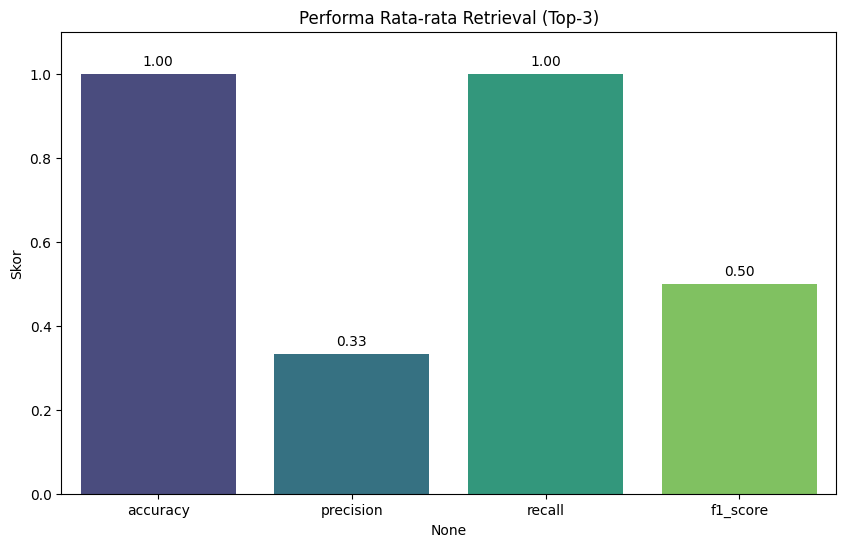

In [50]:
# Simulasi Ground Truth untuk 5 contoh query sebelumnya
# Dalam skenario nyata, ini berasal dari anotasi pakar hukum
ground_truth_sim = [
    ['Case_005'], # Untuk query 1
    ['Case_010'], # Untuk query 2
    ['Case_004'], # Untuk query 3
    ['Case_009'], # Untuk query 4
    ['Case_002']  # Untuk query 5
]

# Mengambil hasil retrieval dari dataframe predictions_df sebelumnya
retrieval_results = predictions_df['top_k_case_ids_majority_vote'].str.split(', ').tolist()

# Menghitung metrik
eval_df = eval_retrieval(retrieval_results, ground_truth_sim, k=3)
summary_metrics = eval_df.mean()

print("Ringkasan Metrik Evaluasi Retrieval:")
display(summary_metrics)

# Visualisasi Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x=summary_metrics.index, y=summary_metrics.values, palette='viridis')
plt.title('Performa Rata-rata Retrieval (Top-3)')
plt.ylabel('Skor')
plt.ylim(0, 1.1)
for i, v in enumerate(summary_metrics.values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
plt.show()

### iii. Output Metrik ke CSV

Menyimpan hasil evaluasi ke folder `/data/eval/`.

In [51]:
eval_dir = '/content/drive/MyDrive/Umm/SEMESTER 6/Penalaran_komputer/TUGAS_3_AKHIR/raw_pdf/data/eval'
os.makedirs(eval_dir, exist_ok=True)

eval_df.to_csv(os.path.join(eval_dir, 'retrieval_metrics.csv'), index=False)
summary_metrics.to_csv(os.path.join(eval_dir, 'prediction_metrics.csv'))

print(f"File evaluasi telah disimpan di: {eval_dir}")

File evaluasi telah disimpan di: /content/drive/MyDrive/Umm/SEMESTER 6/Penalaran_komputer/TUGAS_3_AKHIR/raw_pdf/data/eval


In [35]:
print('Checking for missing values in predictions_df:')
display(predictions_df.isnull().sum())

Checking for missing values in predictions_df:


,0
query_id,0
query_text,0
predicted_solution_majority_vote,0
top_k_case_ids_majority_vote,0
predicted_solution_weighted_sim,0
top_k_case_ids_weighted_sim,0


In [36]:
display(predictions_df.head())

,query_id,query_text,predicted_solution_majority_vote,top_k_case_ids_majority_vote,predicted_solution_weighted_sim,top_k_case_ids_weighted_sim
0,query_1,A new case involving a minor theft accusation.,[putusan_1871_k_pid.sus_2009_20260625110842 (1...,putusan_1871_k_pid.sus_2009_20260625110842 (1)...,[putusan_1871_k_pid.sus_2009_20260625110842 (1...,putusan_1871_k_pid.sus_2009_20260625110842 (1)...
1,query_2,A complex civil case regarding contract fulfil...,[putusan_985_k_pid.sus_2010_20260625110939 (1)...,"putusan_985_k_pid.sus_2010_20260625110939 (1),...",[putusan_985_k_pid.sus_2010_20260625110939 (1)...,"putusan_985_k_pid.sus_2010_20260625110939 (1),..."
2,query_3,Charges of financial fraud against a corporate...,[putusan_605_k_pid.sus_2013_20260625111051 (1)...,"putusan_605_k_pid.sus_2013_20260625111051 (1),...",[putusan_605_k_pid.sus_2013_20260625111051 (1)...,"putusan_605_k_pid.sus_2013_20260625111051 (1),..."
3,query_4,A case of property damage and demand for resti...,[Case_001] n dalam lingkup rumah tangga sebaga...,"Case_001, Case_004, Case_005",[Case_001] n dalam lingkup rumah tangga sebaga...,"Case_001, Case_004, Case_005"
4,query_5,An appeal of a previous drug possession convic...,"[Case_002] itu , permohonan kasasi Oditur \nMi...","Case_002, Case_003, Case_004","[Case_002] itu , permohonan kasasi Oditur \nMi...","Case_002, Case_003, Case_004"
